In [37]:
using NCDatasets, Plots, Dates, Downloads

In [38]:
# Load the NetCDF files from the specified directory
data_dir = "datafiles" # Directory to store downloaded NetCDF files
pat = r"^chesapeake_salinity_(\d{8})_t(\d{2})z_n(\d{3})\.nc$" # Regular expression pattern to match the desired NetCDF files
files = filter(f -> occursin(pat, f), readdir(data_dir)) # Filter files in the data directory that match the pattern

# Check if any files were found
if isempty(files)
    error("No files found matching chesapeake_salinity_YYYYMMDD_tCCz_nFFF.nc")
end

# Sort the files based on the date and time extracted from the filename
frames = NamedTuple[]
for f in files
    m = match(pat, f)
    ymd = m.captures[1]
    cyc = parse(Int, m.captures[2])   # cycle hour
    fh  = parse(Int, m.captures[3])   # forecast/nowcast hour
    dt = DateTime(ymd, dateformat"yyyymmdd") + Hour(cyc) + Hour(fh)
    push!(frames, (file="$data_dir/$f", dt=dt))
end
sort!(frames, by = x -> x.dt)

"""
Load surface salinity data from a NetCDF file.

Arguments:
- file: Path to the NetCDF file

Returns:
- lon_valid: Valid longitude values
- lat_valid: Valid latitude values
- salt_valid: Valid salinity values
"""
function load_surface_salinity(file)
    # Open the NetCDF file
    ds = NCDataset(file)

    # Extract latitude, longitude, and surface salinity data
    lon = ds["lon_rho"][:]
    lat = ds["lat_rho"][:]
    salt = ds["salt"][:,:,end,1]
    
    # Close the file
    close(ds)

    # Filter out invalid data (missing values, NaNs, and values greater than 100)
    valid_idx = .!ismissing.(salt) .&& .!isnan.(salt) .&& (salt .< 100)

    # Extract valid longitude, latitude, and salinity values
    if size(lon) == size(valid_idx) && size(lat) == size(valid_idx)
        lon_valid = lon[valid_idx]
        lat_valid = lat[valid_idx]
    elseif ndims(lon) == 1 && length(lon) == length(vec(valid_idx))
        lon2 = reshape(lon, size(valid_idx))
        lat2 = reshape(lat, size(valid_idx))
        lon_valid = lon2[valid_idx]
        lat_valid = lat2[valid_idx]
    else
        lon_valid = vec(lon)[vec(valid_idx)]
        lat_valid = vec(lat)[vec(valid_idx)]
    end

    return lon_valid, lat_valid, Float64.(salt[valid_idx])
end

load_surface_salinity

In [39]:
include("cb_variograms.jl")

Main.Variograms

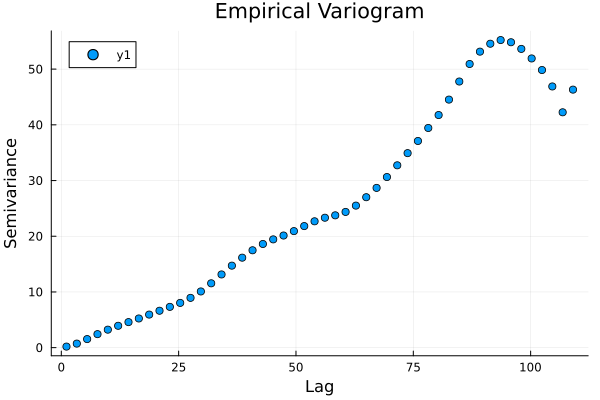

In [40]:
lat_min, lat_max = 36.75, 37.5
lon_min, lon_max = -76.5, -75.5

file = frames[20].file

lon, lat, salt = load_surface_salinity(file)

# For using multiple files
#lon_all = Float64[]
#lat_all = Float64[]
#salt_all = Float64[]

#for fr in frames
    #loni, lati, salti = load_surface_salinity(fr.file)
    #append!(lon_all, loni)
    #append!(lat_all, lati)
    #append!(salt_all, salti)
#end

# lon, lat, salt = lon_all, lat_all, salt_all

roi = (lat .>= lat_min) .& (lat .<= lat_max) .& (lon .>= lon_min) .& (lon .<= lon_max)
good_lons = lon[roi]
good_lats = lat[roi]
good_sals = salt[roi]

#coords = hcat(good_lons, good_lats)
#h, γ = Variograms.pairwise_distances(good_lons, good_lats, good_sals)

# compute empirical variogram (adjust nbins/maxlag as needed)
bins = Variograms.empirical_spatial_variogram(good_lons, good_lats, good_sals)

lags = bins.h_mid
γ_emp = bins.variogram

# plot empirical variogram
scatter(lags, γ_emp, xlabel="Lag", ylabel="Semivariance", title="Empirical Variogram")

In [41]:
hp_model = Variograms.hp_fit(good_lons, good_lats, good_sals)
println(hp_model)

(1078.3845760807985, 2.3925367011101125e6)


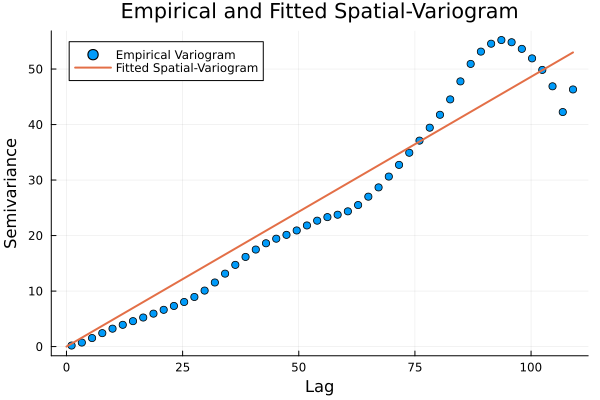

In [42]:
lag_grid = range(0, stop=maximum(lags), length=200)
γ_model = Variograms.spatio_variogram(lag_grid, hp_model)

scatter(lags, γ_emp,
    label="Empirical Variogram",
    xlabel="Lag",
    ylabel="Semivariance",
    title="Empirical and Fitted Spatial-Variogram"
)
plot!(lag_grid, γ_model, label="Fitted Spatial-Variogram", lw=2)

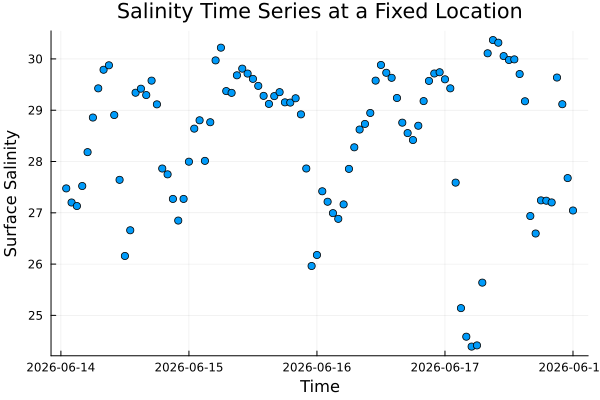

In [43]:
target_lon = (lon_min + lon_max) / 2 -0.1
target_lat = (lat_min + lat_max) / 2

function nearest_grid_index(lon, lat, target_lon, target_lat)
    d2 = (lon .- target_lon).^2 .+ (lat .- target_lat).^2
    return argmin(d2)
end

lon0, lat0, salt0 = load_surface_salinity(frames[1].file)
idx = nearest_grid_index(lon0, lat0, target_lon, target_lat)

times = DateTime[]
salinity_ts = Float64[]

for fr in frames
    _, _, salt = load_surface_salinity(fr.file)
    val = salt[idx]
    push!(times, fr.dt)
    push!(salinity_ts,
        ismissing(val) || isnan(val) || val >= 100 ? NaN : Float64(val))
end

plot(times, salinity_ts,
    seriestype = :scatter,
    xlabel = "Time",
    ylabel = "Surface Salinity",
    title = "Salinity Time Series at a Fixed Location",
    legend = false
)

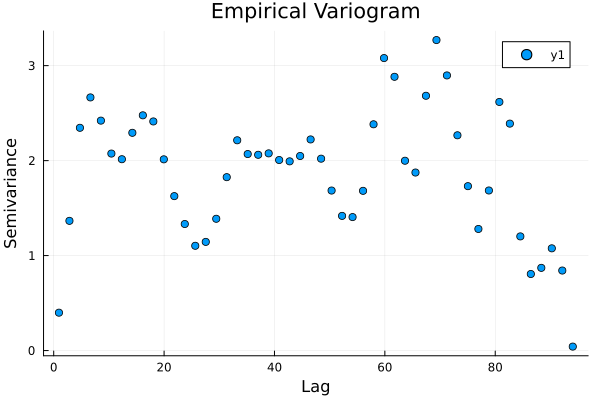

In [44]:
# compute empirical variogram (adjust nbins/maxlag as needed)
bins = Variograms.empirical_temporal_variogram(times, salinity_ts)

lags = bins.h_mid
γ_emp = bins.variogram

# plot empirical variogram
scatter(lags, γ_emp, xlabel="Lag", ylabel="Semivariance", title="Empirical Variogram")

In [45]:
hp_temp_model = Variograms.hp_fit(times, salinity_ts)
println(hp_temp_model)

(1.0, 0.014161098285770514, 0.8448785940004004)


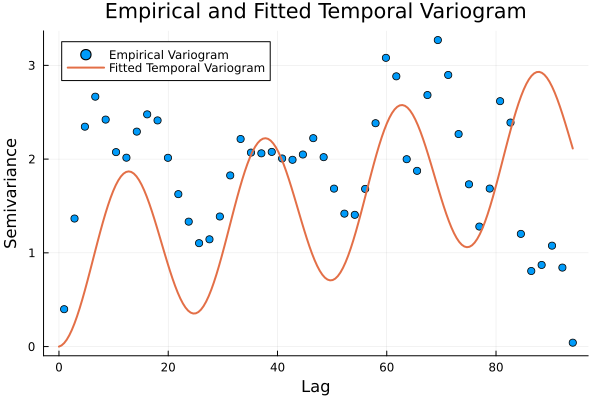

In [46]:
lag_grid = range(0, stop=maximum(lags), length=200)
γ_model = Variograms.temporal_variogram(lag_grid, hp_temp_model)

scatter(lags, γ_emp,
    label="Empirical Variogram",
    xlabel="Lag",
    ylabel="Semivariance",
    title="Empirical and Fitted Temporal Variogram"
)
plot!(lag_grid, γ_model, label="Fitted Temporal Variogram", lw=2)
